# CSE 256:  NLP UCSD, PA3 PART A
## Text Decoding From GPT-2 using Beam Search (40 points)
### <font color='blue'>  Out: February 23 || Due: Thurday 12 March, 2026 </font>

<font color="red"> Make sure to also complete PART B of this PA (the RAG part) in a separate notebook, available in the same directory where you found this notebook. </font>

If Colab is slow, download the notebook to your local machine.
Then one done, upload it to Colab to get a link.



###### IMPORTANT: After copying this notebook to your Google Drive, paste a link to it below. To get a publicly-accessible link, click the *Share* button at the top right, then click "Get shareable link" and copy the link.
#### <font color="red">Link: paste your link here:  </font>
https://drive.google.com/drive/folders/1nwNvnS7kKtOp3Wv3gSIji6qj9LYjHFAM?usp=sharing


---
**Notes:**

Make sure to save the notebook as you go along.

Submission instructions are located at the bottom of the notebook.

There is PART B, dont forget to complete it:

# Part 0: Setup

## Adding a hardware accelerator
Go to the menu and add a GPU as follows:

`Edit > Notebook Settings > Hardware accelerator > (GPU)`

Run the following cell to confirm that the GPU is detected.

In [1]:
import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA:", torch.cuda.get_device_name(), "n_gpu:", torch.cuda.device_count())
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Metal (MPS)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Metal (MPS)


## Installing Hugging Face's Transformers and Additional Libraries
We will use Hugging Face's Transformers (https://github.com/huggingface/transformers).

Run the following cell to install Hugging Face's Transformers library and some other useful tools.

In [2]:
pip install -q sentence-transformers==2.2.2 transformers==4.17.0

Note: you may need to restart the kernel to use updated packages.


# Part 1. Beam Search
We are going to explore decoding from a pretrained GPT-2 model using beam search. Run the below cell to set up some beam search utilities.

In [3]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2", pad_token_id=tokenizer.eos_token_id)
model = model.to(device)
model.eval()

# Beam Search

def init_beam_search(model, input_ids, num_beams):
    assert len(input_ids.shape) == 2
    beam_scores = torch.zeros(num_beams, dtype=torch.float32, device=model.device)
    beam_scores[1:] = -1e9 # Break ties in first round.
    new_input_ids = input_ids.repeat_interleave(num_beams, dim=0).to(model.device)
    return new_input_ids, beam_scores


def run_beam_search_(model, tokenizer, input_text, num_beams=5, num_decode_steps=10, score_processors=[], to_cpu=True):

    input_ids = tokenizer.encode(input_text, return_tensors='pt')

    input_ids, beam_scores = init_beam_search(model, input_ids, num_beams)

    token_scores = beam_scores.clone().view(num_beams, 1)

    model_kwargs = {}
    for i in range(num_decode_steps):
        model_inputs = model.prepare_inputs_for_generation(input_ids, **model_kwargs)
        outputs = model(**model_inputs, return_dict=True)
        next_token_logits = outputs.logits[:, -1, :]
        vocab_size = next_token_logits.shape[-1]
        this_token_scores = torch.log_softmax(next_token_logits, -1)

        # Process token scores.
        processed_token_scores = this_token_scores
        for processor in score_processors:
            processed_token_scores = processor(input_ids, processed_token_scores)

        # Update beam scores.
        next_token_scores = processed_token_scores + beam_scores.unsqueeze(-1)

        # Reshape for beam-search.
        next_token_scores = next_token_scores.view(num_beams * vocab_size)

        # Find top-scoring beams.
        next_token_scores, next_tokens = torch.topk(
            next_token_scores, num_beams, dim=0, largest=True, sorted=True
        )

        # Transform tokens since we reshaped earlier.
        next_indices = torch.div(next_tokens, vocab_size, rounding_mode="floor") # This is equivalent to `next_tokens // vocab_size`
        next_tokens = next_tokens % vocab_size

        # Update tokens.
        input_ids = torch.cat([input_ids[next_indices, :], next_tokens.unsqueeze(-1)], dim=-1)

        # Update beam scores.
        beam_scores = next_token_scores

        # Update token scores.

        # UNCOMMENT: To use original scores instead.
        # token_scores = torch.cat([token_scores[next_indices, :], this_token_scores[next_indices, next_tokens].unsqueeze(-1)], dim=-1)
        token_scores = torch.cat([token_scores[next_indices, :], processed_token_scores[next_indices, next_tokens].unsqueeze(-1)], dim=-1)

        # Update hidden state.
        model_kwargs = model._update_model_kwargs_for_generation(outputs, model_kwargs, is_encoder_decoder=False)
        model_kwargs["past"] = model._reorder_cache(model_kwargs["past"], next_indices)

    def transfer(x):
      return x.cpu() if to_cpu else x

    return {
        "output_ids": transfer(input_ids),
        "beam_scores": transfer(beam_scores),
        "token_scores": transfer(token_scores)
    }


def run_beam_search(*args, **kwargs):
    with torch.inference_mode():
        return run_beam_search_(*args, **kwargs)


# Add support for colored printing and plotting.

from rich import print as rich_print

import numpy as np

import matplotlib
from matplotlib import pyplot as plt
from matplotlib import cm

RICH_x = np.linspace(0.0, 1.0, 50)
RICH_rgb = (matplotlib.colormaps.get_cmap(plt.get_cmap('RdYlBu'))(RICH_x)[:, :3] * 255).astype(np.int32)[range(5, 45, 5)]


def print_with_probs(words, probs, prefix=None):
  def fmt(x, p, is_first=False):
    ix = int(p * RICH_rgb.shape[0])
    r, g, b = RICH_rgb[ix]
    if is_first:
      return f'[bold rgb(0,0,0) on rgb({r},{g},{b})]{x}'
    else:
      return f'[bold rgb(0,0,0) on rgb({r},{g},{b})] {x}'
  output = []
  if prefix is not None:
    output.append(prefix)
  for i, (x, p) in enumerate(zip(words, probs)):
    output.append(fmt(x, p, is_first=i == 0))
  rich_print(''.join(output))

# DEMO

# Show range of colors.

for i in range(RICH_rgb.shape[0]):
  r, g, b = RICH_rgb[i]
  rich_print(f'[bold rgb(0,0,0) on rgb({r},{g},{b})]hello world rgb({r},{g},{b})')

# Example with words and probabilities.

words = ['the', 'brown', 'fox']
probs = [0.14, 0.83, 0.5]
print_with_probs(words, probs)

hello world rgb(215,49,39)

hello world rgb(244,111,68)

hello world rgb(253,176,99)

hello world rgb(254,226,147)

hello world rgb(251,253,196)

hello world rgb(217,239,246)

hello world rgb(163,210,229)

hello world rgb(108,164,204)

the brown fox

## Question 1.1 (5 points)

Run the cell below. It produces a sequence of tokens using beam search and the provided prefix.

In [4]:
num_beams = 5
num_decode_steps = 10
input_text = 'The brown fox jumps'

beam_output = run_beam_search(model, tokenizer, input_text, num_beams=num_beams, num_decode_steps=num_decode_steps)
for i, tokens in enumerate(beam_output['output_ids']):
    score = beam_output['beam_scores'][i]
    print(i, round(score.item() / tokens.shape[-1], 3), tokenizer.decode(tokens, skip_special_tokens=True))


0 -1.106 The brown fox jumps out of the fox's mouth, and the fox
1 -1.168 The brown fox jumps out of the fox's cage, and the fox
2 -1.182 The brown fox jumps out of the fox's mouth and starts to run
3 -1.192 The brown fox jumps out of the fox's mouth and begins to lick
4 -1.199 The brown fox jumps out of the fox's mouth and begins to bite


To get you more acquainted with the code, let's do a simple exercise first. Write your own code in the cell below to generate 3 tokens with a beam size of 4, and then print out the **third most probable** output sequence found during the search. Use the same prefix as above.

In [5]:
input_text = 'The brown fox jumps'

beam_output = run_beam_search(
    model,
    tokenizer,
    input_text,
    num_beams=4,
    num_decode_steps=3
)

for i, tokens in enumerate(beam_output['output_ids']):
    score = beam_output['beam_scores'][i]
    print(i, round(score.item() / tokens.shape[-1], 3), tokenizer.decode(tokens, skip_special_tokens=True))

print("Third most probable output:")
tokens = beam_output['output_ids'][2]
score = beam_output['beam_scores'][2]
print(round(score.item() / tokens.shape[-1], 3), tokenizer.decode(tokens, skip_special_tokens=True))

0 -0.424 The brown fox jumps out of the
1 -0.579 The brown fox jumps out of his
2 -0.627 The brown fox jumps up and down
3 -0.744 The brown fox jumps out of her
Third most probable output:
-0.627 The brown fox jumps up and down


## Question 1.2 (5 points)

Run the cell below to visualize the probabilities the model assigns for each generated word when using beam search with beam size 1 (i.e., greedy decoding).

Visualizeation with plot:


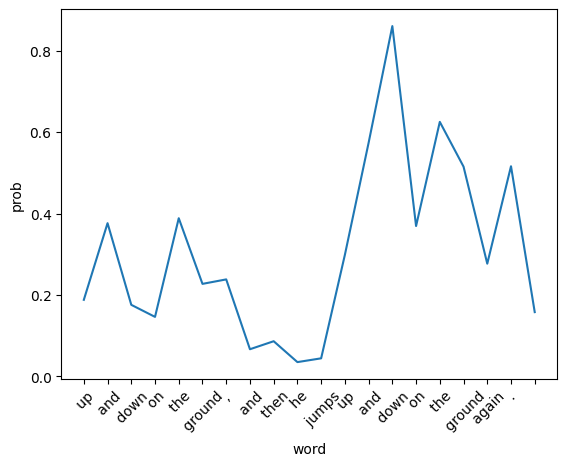

Visualization with colored text (red for lower probability, and blue for higher):


The  brown  fox  jumps up  and  down  on  the  ground ,  and  then  he  jumps  up  and  down  on  the  ground  
again . 

In [6]:
input_text = 'The brown fox jumps'
beam_output = run_beam_search(model, tokenizer, input_text, num_beams=1, num_decode_steps=20)
probs = beam_output['token_scores'][0, 1:].exp()
output_subwords = [tokenizer.decode(tok, skip_special_tokens=True) for tok in beam_output['output_ids'][0]]

print('Visualizeation with plot:')

fig, ax = plt.subplots()
plt.plot(range(len(probs)), probs)
ax.set_xticks(range(len(probs)))
ax.set_xticklabels(output_subwords[-len(probs):], rotation = 45)
plt.xlabel('word')
plt.ylabel('prob')
plt.show()

print('Visualization with colored text (red for lower probability, and blue for higher):')

print_with_probs(output_subwords[-len(probs):], probs, ' '.join(output_subwords[:-len(probs)]))

Why does the model assign higher probability to tokens generated later than to tokens generated earlier?

#### <font color="red">Write your answer here </font>
I found that the model assigns higher probabilities to later tokens because it leverages a increasingly specific context. Initially, my prompt is underspecified, leading to a diffuse probability distribution across many possible continuations. As more tokens are generated, grammar and semantic rules constrain the sequence. This reduces the model's uncertainty, leading to a highly peaked distribution where the top token naturally receives a higher probability.




Run the cell below to visualize the word probabilities when using different beam sizes.

Visualization with plot:


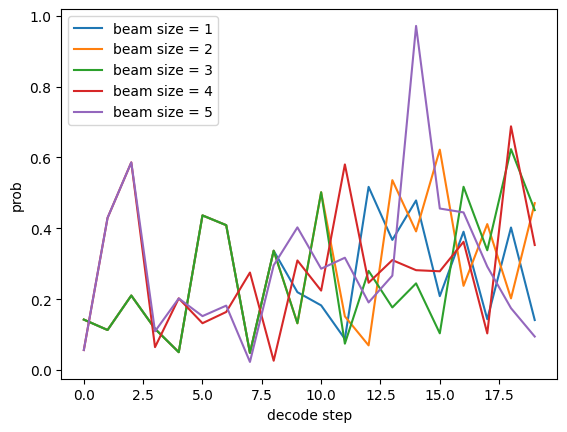

Model predictions:
1 -0.9706205888227983 Once upon a time, in a barn near a farm house, a young boy was playing with a stick. He was playing with a stick, and the boy was
2 -0.9286171884247751 Once upon a time, in a barn near a farm house, a young boy was playing with a stick. The boy was playing with a stick, and the boy
3 -0.9597559842196378 Once upon a time, in a barn near a farm house, a young boy was playing with a stick. The boy, who had been playing with a stick,
4 -0.9205139622543798 Once upon a time, in a barn near a farm house, there was a young girl who had been brought up by her mother. She had been brought up by
5 -0.9058736165364584 Once upon a time, in a barn near a farm house, there was a man who had been living in the house for a long time. He was a man


In [7]:
input_text = 'Once upon a time, in a barn near a farm house,'
num_decode_steps = 20
model = model.to(device)

beam_size_list = [1, 2, 3, 4, 5]
output_list = []
probs_list = []
for bm in beam_size_list:
  beam_output = run_beam_search(model, tokenizer, input_text, num_beams=bm, num_decode_steps=num_decode_steps)
  output_list.append(beam_output)
  probs = beam_output['token_scores'][0, 1:].exp()
  probs_list.append((bm, probs))

print('Visualization with plot:')
fig, ax = plt.subplots()
for bm, probs in probs_list:
  plt.plot(range(len(probs)), probs, label=f'beam size = {bm}')
plt.xlabel('decode step')
plt.ylabel('prob')
plt.legend(loc='best')
plt.show()

print('Model predictions:')
for bm, beam_output in zip(beam_size_list, output_list):
  tokens = beam_output['output_ids'][0]
  print(bm, beam_output['beam_scores'][0].item() / tokens.shape[-1], tokenizer.decode(tokens, skip_special_tokens=True))

## Question 1.3 (10 points)

Beam search often results in repetition in the predicted tokens. In the following cell we pass a score processor called `WordBlock` to `run_beam_search`. At each time step, it reduces the probability for any previously seen word so that it is not generated again.

Run the cell to see how the output of beam search changes with and without using `WordBlock`.

In [8]:
import collections

class WordBlock:
    def __call__(self, input_ids, scores):
        for batch_idx in range(input_ids.shape[0]):
            for x in input_ids[batch_idx].tolist():
                scores[batch_idx, x] = -1e9
        return scores

input_text = 'Once upon a time, in a barn near a farm house,'
num_beams = 1

print('Beam Search')
beam_output = run_beam_search(model, tokenizer, input_text, num_beams=num_beams, num_decode_steps=40, score_processors=[])
print(tokenizer.decode(beam_output['output_ids'][0], skip_special_tokens=True))

print('Beam Search w/ Word Block')
beam_output = run_beam_search(model, tokenizer, input_text, num_beams=num_beams, num_decode_steps=40, score_processors=[WordBlock()])
print(tokenizer.decode(beam_output['output_ids'][0], skip_special_tokens=True))


Beam Search
Once upon a time, in a barn near a farm house, a young boy was playing with a stick. He was playing with a stick, and the boy was playing with a stick. The boy was playing with a stick, and the boy was playing with a
Beam Search w/ Word Block
Once upon a time, in a barn near a farm house, the young girl was playing with her father's dog. She had been told that she would be given to him by his wife and he could take care of it for herself if needed; but when they


Is `WordBlock` a practical way to prevent repetition in beam search? What (if anything) could go wrong when using `WordBlock`?

#### <font color="red">Write your answer here </font>
I concluded that WordBlock is generally too blunt to be a practical way to prevent repetition in beam search. Even though it easily suppresses obvious repetitive loops, I found that it aggressively forbids any previously seen word from appearing again. This completely disregards the fact that natural language needs to reuse articles, pronouns, prepositions, and key content words. Consequently, the text becomes unnatural, less fluent, and ungrammatical. Essentially, I noticed that WordBlock constantly over-corrects by failing to distinguish between pathological repetition and legitimate word reuse.

## Question 1.4 (20 points)

Use the previous `WordBlock` example to write a new score processor called `BeamBlock`. Instead of uni-grams, your implementation should prevent tri-grams from appearing more than once in the sequence.

Note: This technique is called "beam blocking" and is described [here](https://arxiv.org/pdf/1705.04304.pdf) (section 2.5). Also, for this assignment you do not need to re-normalize your output distribution after masking values, although typically re-normalization is done.

Write your code in the indicated section in the below cell.

In [9]:
import collections

class BeamBlock:
    def __call__(self, input_ids, scores):
        for batch_idx in range(input_ids.shape[0]):
            tokens = input_ids[batch_idx].tolist()

            if len(tokens) < 3:
                continue

            trigrams = set()
            for i in range(len(tokens) - 2):
                trigrams.add((tokens[i], tokens[i + 1], tokens[i + 2]))

            prefix = (tokens[-2], tokens[-1])

            for trigram in trigrams:
                if trigram[0] == prefix[0] and trigram[1] == prefix[1]:
                    blocked_token = trigram[2]
                    scores[batch_idx, blocked_token] = -1e9

        return scores

input_text = 'Once upon a time, in a barn near a farm house,'
num_beams = 1

print('Beam Search')
beam_output = run_beam_search(model, tokenizer, input_text, num_beams=num_beams, num_decode_steps=40, score_processors=[])
print(tokenizer.decode(beam_output['output_ids'][0], skip_special_tokens=True))

print('Beam Search w/ Beam Block')
beam_output = run_beam_search(model, tokenizer, input_text, num_beams=num_beams, num_decode_steps=40, score_processors=[BeamBlock()])
print(tokenizer.decode(beam_output['output_ids'][0], skip_special_tokens=True))


Beam Search
Once upon a time, in a barn near a farm house, a young boy was playing with a stick. He was playing with a stick, and the boy was playing with a stick. The boy was playing with a stick, and the boy was playing with a
Beam Search w/ Beam Block
Once upon a time, in a barn near a farm house, a young boy was playing with a stick. He was playing on the stick, and the boy was trying to get a ball. The boy was holding the stick in his hand, and he was trying




# <font color="blue"> Submission Instructions</font>
---------------------------

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Cell -> All Output -> Clear. This will clear all the outputs from all cells (but will keep the content of all cells).
2. Select Cell -> Run All. This will run all the cells in order, and will take several minutes.
3. Once you've rerun everything, convert the notebook to PDF, you can use tools such as [nbconvert](https://nbconvert.readthedocs.io/en/latest/usage.html), which requires first downloading the  ipynb  to your local machine, and then running "nbconvert" . (If you have trouble using nbconvert, you can also save the webpage as pdf. <font color='blue'> Make sure all your solutions  are displayed in the pdf</font>, it's okay if the provided codes get cut off because lines are not wrapped in code cells).
4. Look at the PDF file and make sure all your solutions are there, displayed correctly. The PDF is the only thing your graders will see!
5. Combine your PDFs and submit your combined PDF on Gradescope (Both Parts A DECODING + PART B - RAG)

#### <font color="blue"> Acknowledgements</font>
This part of the PA is based on a PA  developed by Mohit Iyyer